In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Function 6: Cake and Stuff

Time to get cooking! You are optimising a cake recipe. There are five ingredients. The outputs correspond to the sum of different objectives: flavor, consistency, calories, waste and cost. Each objective receives negative points by our expert taster. You want this sum to be as close to zero as possible!

In [77]:
import ast
import numpy as np

def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = ast.literal_eval(formatted_query)  # Use ast.literal_eval for safety
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [78]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.7281861 , 0.15469257, 0.73255167, 0.69399651, 0.05640131],
        [0.24238435, 0.84409997, 0.5778091 , 0.67902128, 0.50195289],
        [0.72952261, 0.7481062 , 0.67977464, 0.35655228, 0.67105368],
        [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
        [0.6188123 , 0.33180214, 0.18728787, 0.75623847, 0.3288348 ],
        [0.78495809, 0.91068235, 0.7081201 , 0.95922543, 0.0049115 ],
        [0.14511079, 0.8966846 , 0.89632223, 0.72627154, 0.23627199],
        [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
        [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
        [0.75759436, 0.35583141, 0.0165229 , 0.4342072 , 0.11243304],
        [0.5367969 , 0.30878091, 0.41187929, 0.38822518, 0.5225283 ],
        [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
        [0.6293079 , 0.80348368, 0.81140844, 0.04561319, 0.11062446],
        [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
        [0.43934426,

In [79]:
queries = queries_for_function(6)
X = np.vstack([X, queries])
X, len(X)

(array([[7.28186105e-01, 1.54692570e-01, 7.32551669e-01, 6.93996509e-01,
         5.64013105e-02],
        [2.42384347e-01, 8.44099972e-01, 5.77809099e-01, 6.79021284e-01,
         5.01952888e-01],
        [7.29522610e-01, 7.48106200e-01, 6.79774641e-01, 3.56552279e-01,
         6.71053683e-01],
        [7.70620242e-01, 1.14403744e-01, 4.67799319e-02, 6.48324285e-01,
         2.73549053e-01],
        [6.18812299e-01, 3.31802137e-01, 1.87287868e-01, 7.56238474e-01,
         3.28834798e-01],
        [7.84958094e-01, 9.10682349e-01, 7.08120104e-01, 9.59225429e-01,
         4.91149586e-03],
        [1.45110786e-01, 8.96684598e-01, 8.96322235e-01, 7.26271537e-01,
         2.36271991e-01],
        [9.45069068e-01, 2.88459051e-01, 9.78805764e-01, 9.61655587e-01,
         5.98015936e-01],
        [1.25720155e-01, 8.62724692e-01, 2.85443322e-02, 2.46605272e-01,
         7.51206241e-01],
        [7.57594355e-01, 3.55831415e-01, 1.65228997e-02, 4.34207205e-01,
         1.12433044e-01],
        [5

In [80]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([-0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
        -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
        -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254 ,
        -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209]),
 20)

In [81]:
observations = observations_for_function(6)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([-0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
        -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
        -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254 ,
        -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
        -0.66414024, -1.99930487, -1.90577291, -1.75070097, -2.04759996,
        -1.12944776, -2.37813635, -1.72555488, -1.66306524, -1.93238149,
        -1.33020289]),
 31)

In [82]:
def best_observation(y):
    best_idx = np.argmin(np.abs(y))  # Find the index where y is closest to zero
    best_observation_so_far = y[best_idx]
    best_query_so_far = X[best_idx]
    print("Best observation so far (closest to zero):", best_observation_so_far)
    print("Best query so far:", best_query_so_far)
    return best_observation_so_far, best_query_so_far

best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): -0.6641402405779638
Best query so far: [0.333334 0.222223 0.555555 0.999999 0.222223]


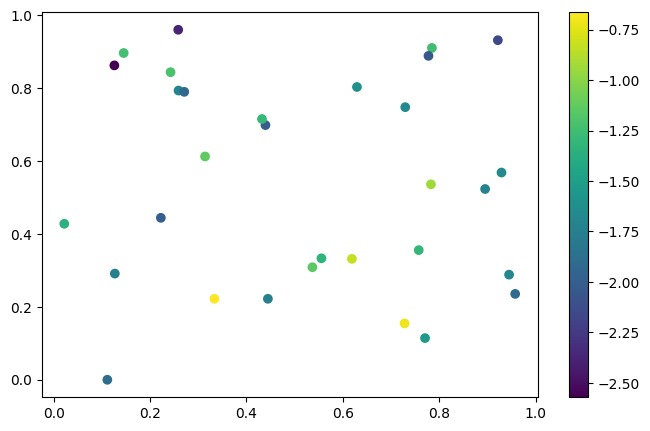

In [83]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

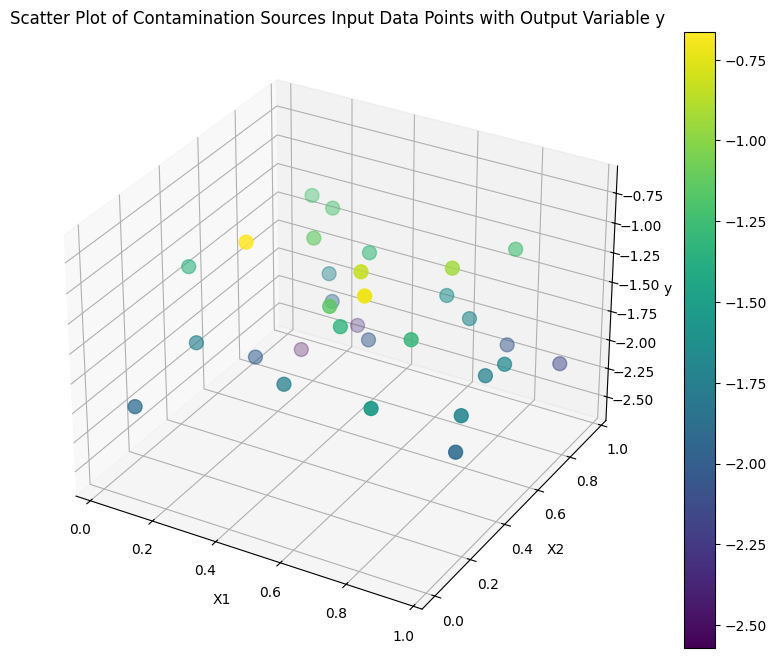

In [84]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


**Acquisition Functions**

In [85]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

**Input Sampling Methods**

In [86]:
def exploration_grid():
    x1_grid = np.linspace(0.000001, 0.999999, 10)
    x2_grid = np.linspace(0.000001, 0.999999, 10)
    x3_grid = np.linspace(0.000001, 0.999999, 10)
    x4_grid = np.linspace(0.000001, 0.999999, 10)
    x5_grid = np.linspace(0.000001, 0.999999, 10)

    x1_grid, x2_grid, x3_grid, x4_grid, x5_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid, x5_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(),  x4_grid.ravel(),  x5_grid.ravel()]).T

    return x_grid

def exploitation_grid(center, delta=0.05):
    """
    Create a grid for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    x1, x2, x3, x4, x5 = center
    x1_grid = np.linspace(max(0.000001, x1 - delta), min(0.999999, x1 + delta), 10)
    x2_grid = np.linspace(max(0.000001, x2 - delta), min(0.999999, x2 + delta), 10)
    x3_grid = np.linspace(max(0.000001, x3 - delta), min(0.999999, x3 + delta), 10)
    x4_grid = np.linspace(max(0.000001, x4 - delta), min(0.999999, x4 + delta), 10)
    x5_grid = np.linspace(max(0.000001, x5 - delta), min(0.999999, x5 + delta), 10)

    x1_grid, x2_grid, x3_grid, x4_grid, x5_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid, x5_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(), x4_grid.ravel(), x5_grid.ravel()]).T

    return x_grid

def exploration_latin_hypercube():
    """
    Create a Latin Hypercube sample for exploration.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (0.000001, 0.999999),  # x1
        (0.000001, 0.999999),  # x2
        (0.000001, 0.999999),  # x3
        (0.000001, 0.999999),  # x4
        (0.000001, 0.999999)   # x5
    ]
    sampler = qmc.LatinHypercube(d=5)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

def exploitation_latin_hypercube(center, delta=0.05):
    """
    Create a Latin Hypercube sample for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (max(0.000001, center[0] - delta), min(0.999999, center[0] + delta)),  # x1
        (max(0.000001, center[1] - delta), min(0.999999, center[1] + delta)),  # x2
        (max(0.000001, center[2] - delta), min(0.999999, center[2] + delta)),  # x3
        (max(0.000001, center[3] - delta), min(0.999999, center[3] + delta)),  # x4
        (max(0.000001, center[4] - delta), min(0.999999, center[4] + delta))   # x4
    ]
    sampler = qmc.LatinHypercube(d=5)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

In [87]:
def query_black_box_function_with_default_kernel(X, y, x_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)
       
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    next_query = next_query.reshape(1,5)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
   
    return next_query, y_pred

In [88]:
def next_query_with_default_kernel(X, y, x_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

**Exploration**

Explore the whole space with **defalut** RBF Kernel

In [89]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploration_grid())

Random Query: 0.259970-0.583016


UCB Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.333334-0.000001-0.999999-0.000001)
Predicted Value at (0.000001-0.333334-0.000001-0.999999-0.000001) is -0.02024025554378639)
Index of maximum acquisition function value:  30090


PI Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.444445-0.333334-0.444445-0.888888-0.222223)
Predicted Value at (0.444445-0.333334-0.444445-0.888888-0.222223) is -0.4752998161726687)
Index of maximum acquisition function value:  34482


PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.111112-0.333334-0.000001-0.999999-0.000001)
Predicted Value at (0.111112-0.333334-0.000001-0.999999-0.000001) is 0.005759059882780804)
Index of maximum acquisition function value:  31090


EI Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.111112-0.333334-0.000001-0.888888-0.000001)
Predicted Value at (0.111112-0.333334-0.0000

**Exploitation**

In [90]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): -0.6641402405779638
Best query so far: [0.333334 0.222223 0.555555 0.999999 0.222223]


In [91]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploitation_grid(best_query_so_far))

Random Query: 0.098741-0.162380


UCB Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.283334-0.272223-0.505555-0.949999-0.172223)
Predicted Value at (0.283334-0.272223-0.505555-0.949999-0.172223) is -0.5083653159705044)
Index of maximum acquisition function value:  90000


PI Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.372223-0.250001-0.505555-0.955555-0.227779)
Predicted Value at (0.372223-0.250001-0.505555-0.955555-0.227779) is -0.5602863335916943)
Index of maximum acquisition function value:  78015


PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.283334-0.272223-0.505555-0.949999-0.172223)
Predicted Value at (0.283334-0.272223-0.505555-0.949999-0.172223) is -0.5083653159705044)
Index of maximum acquisition function value:  90000


EI Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.316667-0.272223-0.505555-0.949999-0.172223)
Predicted Value at (0.316667-0.272223-0.505555

**Hyperparameter Tuning using gp_minimize**

In [92]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct
def query_black_box_function_with_hyper_parameters(X, y, x_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-10, 1e10))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-10, 1e10))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-10, 1e10))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)

    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    next_query = next_query.reshape(1, 5)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel Type:", kernel_type)

    return next_query, y_pred

**Hyperparameter Tuning using gp_minimize**

With Full Grid as Search Space

In [93]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

x_grid = exploration_grid()


# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the absolute value of the prediction as we want to get as close to zero as possible
    return np.abs(y_pred[0])

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=50,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.111112-0.333334-0.000001-0.999999-0.000001)
Predicted Value at (0.111112-0.333334-0.000001-0.999999-0.000001) is 0.005759059882780804)
Index of maximum acquisition function value:  31090
Kernel Type: None



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




UCB Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.222223-0.222223-0.999999-0.000001)
Predicted Value at (0.000001-0.222223-0.222223-0.999999-0.000001) is -0.8274971032464364)
Index of maximum acquisition function value:  20290
Kernel Type: RationalQuadratic


EI Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.111112-0.333334-0.000001-0.888888-0.000001)
Predicted Value at (0.111112-0.333334-0.000001-0.888888-0.000001) is 0.008268540112890577)
Index of maximum acquisition function value:  31080
Kernel Type: None


Thompson Samples Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.555555-0.000001-0.888888-0.000001)
Predicted Value at (0.000001-0.555555-0.000001-0.888888-0.000001) is -0.5858606008390197)
Index of maximum acquisition function value:  50080
Kernel Type: RBF


PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.999999-0.999999-0.00000

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.111112-0.999999-0.000001)
Predicted Value at (0.000001-0.000001-0.111112-0.999999-0.000001) is -0.3629986217298722)
Index of maximum acquisition function value:  190
Kernel Type: RBF


EI Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.999999-0.999999-0.000001)
Predicted Value at (0.000001-0.000001-0.999999-0.999999-0.000001) is -0.3072374423730224)
Index of maximum acquisition function value:  990
Kernel Type: DotProduct


PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.222223-0.111112-0.999999-0.000001)
Predicted Value at (0.000001-0.222223-0.111112-0.999999-0.000001) is -0.33350428829387724)
Index of maximum acquisition function value:  20190
Kernel Type: RBF


PI Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.999999-0.999999-0.000001)
P

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




Thompson Samples Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.111112-0.000001-0.888888-0.999999-0.000001)
Predicted Value at (0.111112-0.000001-0.888888-0.999999-0.000001) is -0.3738473504289459)
Index of maximum acquisition function value:  1890
Kernel Type: DotProduct


PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.222223-0.999999-0.000001)
Predicted Value at (0.000001-0.000001-0.222223-0.999999-0.000001) is -0.9142047006179439)
Index of maximum acquisition function value:  290
Kernel Type: RationalQuadratic


PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.222223-0.999999-0.000001)
Predicted Value at (0.000001-0.000001-0.222223-0.999999-0.000001) is -0.9142047006179439)
Index of maximum acquisition function value:  290
Kernel Type: RationalQuadratic


UCB Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.0000

(array([[1.11111889e-01, 3.33333667e-01, 1.00000000e-06, 9.99999000e-01,
         1.00000000e-06]]),
 array([0.00575906]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **gp_minimize**

In [94]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.111112-0.333334-0.000001-0.999999-0.000001)
Predicted Value at (0.111112-0.333334-0.000001-0.999999-0.000001) is 0.005759059882780804)
Index of maximum acquisition function value:  31090
Kernel Type: None


(array([[1.11111889e-01, 3.33333667e-01, 1.00000000e-06, 9.99999000e-01,
         1.00000000e-06]]),
 array([0.00575906]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **gp_minimize**

In [95]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): -0.6641402405779638
Best query so far: [0.333334 0.222223 0.555555 0.999999 0.222223]


In [96]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.283334-0.272223-0.505555-0.949999-0.172223)
Predicted Value at (0.283334-0.272223-0.505555-0.949999-0.172223) is -0.5083653159705044)
Index of maximum acquisition function value:  90000
Kernel Type: None


(array([[0.283334, 0.272223, 0.505555, 0.949999, 0.172223]]),
 array([-0.50836532]))

**Hyperparameter Tuning with BayesianOptimization**

With Full Grid as Search Space

In [97]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

x_grid = exploration_grid()

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative absolute value of the prediction as we want to get as close to zero as possible
    return -np.abs(y_pred[0])

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 4),  # 0:None, 1: RBF, 2: Matern, 3: RationalQuadratic, 4: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.444445-0.333334-0.555555-0.777777-0.000001)
Predicted Value at (0.444445-0.333334-0.555555-0.777777-0.000001) is -0.48806501326743046)
Index of maximum acquisition function value:  34570
Kernel Type: RationalQuadratic
| 1         | -0.4881   | 1.498     | 2.901     | 2.928     | 0.6027    | 0.0156    | 2.34      |



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




UCB Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.333334-0.000001-0.999999-0.000001)
Predicted Value at (0.000001-0.333334-0.000001-0.999999-0.000001) is -0.7702555928228092)
Index of maximum acquisition function value:  30090
Kernel Type: Matern
| 2         | -0.7703   | 0.2323    | 2.732     | 2.404     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.333334-0.333334-0.999999-0.000001)
Predicted Value at (0.000001-0.333334-0.333334-0.999999-0.000001) is -0.28075871040239875)
Index of maximum acquisition function value:  30390
Kernel Type: RBF
| 3         | -0.2808   | 3.33      | 1.425     | 0.7273    | 0.1916    | 0.03042   | 7.871     |


PI With Exploitation Term Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.111112-0.999999-0.000001)
Predicted Value at (0.000001-0.000001-0.111112-0.999999-0.000001) is -0.7531565401209503)
Index of maxim

(array([[1.00000000e-06, 2.22222778e-01, 1.00000000e-06, 8.88888111e-01,
         1.00000000e-06]]),
 array([-0.06039927]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **BayesianOptimization**

In [98]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



Thompson Samples Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.111112-0.222223-0.000001-0.777777-0.000001)
Predicted Value at (0.111112-0.222223-0.000001-0.777777-0.000001) is -0.08501366914867248)
Index of maximum acquisition function value:  21070
Kernel Type: None


(array([[1.11111889e-01, 2.22222778e-01, 1.00000000e-06, 7.77777222e-01,
         1.00000000e-06]]),
 array([-0.08501367]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization**

In [99]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): -0.6641402405779638
Best query so far: [0.333334 0.222223 0.555555 0.999999 0.222223]


In [100]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



Thompson Samples Shape:  (100000,)
Query to Black Box Function Maximizes at Input: (0.283334-0.272223-0.505555-0.955555-0.172223)
Predicted Value at (0.283334-0.272223-0.505555-0.955555-0.172223) is -0.5135891655758762)
Index of maximum acquisition function value:  90010
Kernel Type: None


(array([[0.283334  , 0.272223  , 0.505555  , 0.95555456, 0.172223  ]]),
 array([-0.51358917]))

**Hyperparameter Tuning using BayesianOptimization]**

Latin Hypercube Sampling

In [101]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

lhs_samples = exploration_latin_hypercube()

# Define the function to optimize
def objective_function_bo_lhs(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, lhs_samples,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative absolute value of the prediction as we want to get as close to zero as possible
    return -np.abs(y_pred[0])

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 4),  # 0:None, 1: RBF, 2: Matern, 3: RationalQuadratic, 4: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo_lhs,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, lhs_samples,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.355102-0.407388-0.526916-0.744658-0.015105)
Predicted Value at (0.355102-0.407388-0.526916-0.744658-0.015105) is -0.484547769869593)
Index of maximum acquisition function value:  3775
Kernel Type: RationalQuadratic
| 1         | -0.4845   | 1.498     | 2.901     | 2.928     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.067862-0.576560-0.143620-0.829284-0.011034)
Predicted Value at (0.067862-0.576560-0.143620-0.829284-0.011034) is -0.726996861772907)
Index of maximum acquisition function value:  3392
Kernel Type: Mat


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.175486-0.392755-0.450018-0.942339-0.001162)
Predicted Value at (0.175486-0.392755-0.450018-0.942339-0.001162) is -0.3085910816913966)
Index of maximum acquisition function value:  688
Kernel Type: RBF
| 3         | -0.3086   | 3.33      | 1.425     | 0.7273    | 0.1916    | 0.03042   | 7.871     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.172510-0.089131-0.015876-0.968940-0.045294)
Predicted Value at (0.172510-0.089131-0.015876-0.968940-0.045294) is -0.8126440591917259)
Index of maximum acquisition function value:  9970
Kernel Type: Matern
| 4         | -0.8126   | 1.728     | 1.582     | 2.447     | 0.1481    | 0.02921   | 5.495     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.172510-0.089131-0.015876-0.968940-0.045294)
Predicted Value at (0.172510-0.089131-0.015876-0.968940-0.045294) is -0.49537626626844045

(array([[0.19118627, 0.29333936, 0.11369624, 0.87689607, 0.03231522]]),
 array([-0.06483128]))

**Exploration**

Explore the Latin Hypescale search space with Best Hyperparameters found using **BaysianOptimization on Latin Hypescale Search Space**

In [102]:

next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_latin_hypercube(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.151596-0.468649-0.047245-0.962718-0.000114)
Predicted Value at (0.151596-0.468649-0.047245-0.962718-0.000114) is -0.04095747126199001)
Index of maximum acquisition function value:  5376
Kernel Type: None


(array([[1.51595559e-01, 4.68649049e-01, 4.72448721e-02, 9.62718319e-01,
         1.14161246e-04]]),
 array([-0.04095747]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization on Latin Hypescale Search Space**

In [103]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): -0.6641402405779638
Best query so far: [0.333334 0.222223 0.555555 0.999999 0.222223]


In [104]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_latin_hypercube(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.310108-0.248197-0.508450-0.953035-0.176237)
Predicted Value at (0.310108-0.248197-0.508450-0.953035-0.176237) is -0.52044766095268)
Index of maximum acquisition function value:  2438
Kernel Type: None


(array([[0.31010782, 0.24819652, 0.5084498 , 0.95303487, 0.1762366 ]]),
 array([-0.52044766]))